## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

! pip  install subword-nmt
! pip install nltk
# ! pip install torchtext


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    # !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    !curl -O https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
  1 12.3M    1  192k    0     0  78580      0  0:02:44  0:00:02  0:02:42 78611
  2 12.3M    2  288k    0     0  84178      0  0:02:33  0:00:03  0:02:30 84188
  2 12.3M    2  352k    0     0  79972      0  0:02:41  0:00:04  0:02:37 79992
  3 12.3M    3  432k    0     0  78252      0  0:02:44  0:00:05  0:02:39 85780
  4 12.3M    4  512k    0     0  80059      0  0:02:41  0:00:06  0:02:35  103k
  4 12.3M    4  576k    0     0  78627      0  0:02:44  0:00:07  0:02:37 78643
  4 12.3M    4  608k    0     0  73140      0  0:02:56  0:00:08  0:02:48 65431
  5 12.3M    5  656k    0     0  70546      0  0:03

#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [1]:
# old deprecated code
import torch
import torch.nn as nn
import torch.optim as optim

# import torchtext
# from torchtext.datasets import TranslationDataset, Multi30k
# from torchtext.data import Field, BucketIterator

# import spacy

import random
import math
import time

import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE


In [6]:
! pip install transformers

  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import datasets
from transformers import AutoTokenizer
from datasets import load_dataset

In [3]:
import gc

In [4]:
def clean_memory():
    if 'model' in locals():
        model.to('cpu')
        del model
    gc.collect()
    torch.cuda.empty_cache()
    return

In [6]:
"""
Hugging Face translation dataset formatting:
 {'id': '90560',  //optional
 'translation': {'en': 'But this lofty plateau measured only a few fathoms, and soon we reentered Our Element.',
  'fr': 'Mais ce plateau élevé ne mesurait que quelques toises, et bientôt nous fûmes rentrés dans notre élément.'}}
"""

"\n {'id': '90560',\n 'translation': {'en': 'But this lofty plateau measured only a few fathoms, and soon we reentered Our Element.',\n  'fr': 'Mais ce plateau élevé ne mesurait que quelques toises, et bientôt nous fûmes rentrés dans notre élément.'}}\n"

In [5]:
DATASET_FPATH = r"data.txt"

In [6]:
import os
os.path.isfile(DATASET_FPATH)

True

In [7]:
def txt2dataset(fpath):
    with open(fpath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    data = {"translation": []}
    for line in lines:
        # print(line)
        line_en, line_ru = line.strip().split('\t')
        data["translation"].append({"en":line_en, "ru": line_ru})
    return datasets.Dataset.from_dict(data)

In [8]:
my_dataset = txt2dataset(fpath=DATASET_FPATH)

In [9]:
my_dataset.info

DatasetInfo(description='', citation='', homepage='', license='', features={'translation': {'en': Value('string'), 'ru': Value('string')}}, post_processed=None, supervised_keys=None, builder_name=None, dataset_name=None, config_name=None, version=None, splits=None, download_checksums=None, download_size=None, post_processing_size=None, dataset_size=None, size_in_bytes=None)

In [10]:
print(my_dataset[0])

{'translation': {'en': 'Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.', 'ru': 'Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.'}}


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

#### Reference code

In [ ]:
# tokenizer_W = WordPunctTokenizer()
# def tokenize(x, tokenizer=tokenizer_W):
#     return tokenizer.tokenize(x.lower())

In [ ]:
# SRC = Field(tokenize=tokenize,
#             init_token = '<sos>',
#             eos_token = '<eos>',
#             lower = True)

# TRG = Field(tokenize=tokenize,
#             init_token = '<sos>',
#             eos_token = '<eos>',
#             lower = True)

# dataset = torchtext.data.TabularDataset(
#     path=path_do_data,
#     format='tsv',
#     fields=[('trg', TRG), ('src', SRC)]
# )

In [ ]:
# train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

In [ ]:
# print(f"Number of training examples: {len(train_data.examples)}")
# print(f"Number of validation examples: {len(valid_data.examples)}")
# print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500


In [ ]:
# SRC.build_vocab(train_data, min_freq = 3)
# TRG.build_vocab(train_data, min_freq = 3)

In [ ]:
# print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
# print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (ru) vocabulary: 9267
Unique tokens in target (en) vocabulary: 6699


Here are tokens from original (RU) corpus:

In [ ]:
# SRC.vocab.itos[::1000]

['<unk>',
 '29',
 'соль',
 'комо',
 '―',
 'электрическая',
 'ming',
 'утренний',
 'детском',
 'таунус']

And from target (EN) corpus:

In [ ]:
# TRG.vocab.itos[::1000]

['<unk>', 'king', 'buffets', 'catch', 'media', 'schedule', 'maraunenhof']

And here is example from train dataset:

In [ ]:
# print(vars(train_data.examples[9]))

{'trg': ['laundry', 'service', 'is', 'provided', '.'], 'src': ['помимо', 'этого', ',', 'гостям', 'предоставляются', 'услуги', 'прачечной', '.']}


Let's check the length distributions:

Length distribution in Train data


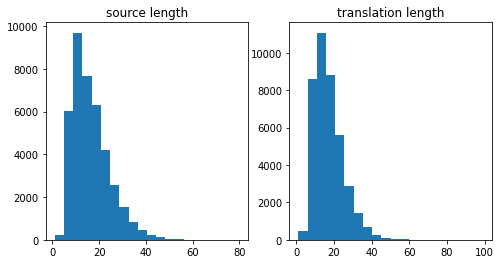

In [ ]:
# src_length = map(len, [vars(x)['src'] for x in train_data.examples])
# trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

# print('Length distribution in Train data')
# plt.figure(figsize=[8, 4])
# plt.subplot(1, 2, 1)
# plt.title("source length")
# plt.hist(list(src_length), bins=20);

# plt.subplot(1, 2, 2)
# plt.title("translation length")
# plt.hist(list(trg_length), bins=20);

Length distribution in Test data


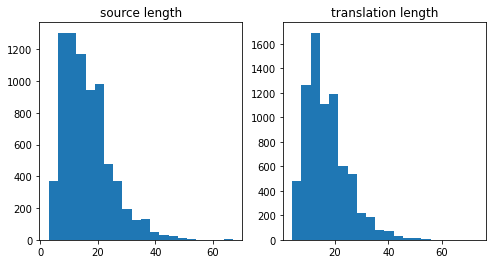

In [ ]:
# src_length = map(len, [vars(x)['src'] for x in test_data.examples])
# trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

# print('Length distribution in Test data')
# plt.figure(figsize=[8, 4])
# plt.subplot(1, 2, 1)
# plt.title("source length")
# plt.hist(list(src_length), bins=20);

# plt.subplot(1, 2, 2)
# plt.title("translation length")
# plt.hist(list(trg_length), bins=20);

#### My implementation

In [11]:
# Train, validation, test split [0.8, 0.15, 0.05]

data1 = my_dataset.train_test_split(test_size=0.20, seed=42)
data2 = data1['test'].train_test_split(test_size=(1 - 0.15 / 0.2), seed=42)
my_dataset = datasets.DatasetDict({
    'train': data1['train'],
    'validation': data2['train'],
    'test': data2['test'],
})

In [12]:
print(f"Train/val/test len: {[len(my_dataset[f]) for f in my_dataset.keys()]}")
print(f"Number of training examples: {len(my_dataset['train'])}")
print(f"Number of validation examples: {len(my_dataset['validation'])}")
print(f"Number of testing examples: {len(my_dataset['test'])}")

Train/val/test len: [40000, 7499, 2501]
Number of training examples: 40000
Number of validation examples: 7499
Number of testing examples: 2501


##### Эксперимент 1: Tokenizer Helsinki-NLP/opus-mt-ru-en
-> слишком большой размер словаря

-> слишком долго обучается

Tokenizer info:

Training Data
*   Pre-processing: Normalization + SentencePiece
*   Dataset: opus

Приведение к нижнему регистру не делается.

In [16]:
# Pre-trained tokenizer (reference: https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ru-en")
source_lang = "ru"
target_lang = "en"
prefix = "translate Russian to English: "

config.json: 0.00B [00:00, ?B/s]

X:\repos\venvs\adv_ml\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-ru-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

X:\repos\venvs\adv_ml\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [17]:
print(tokenizer)

MarianTokenizer(name_or_path='Helsinki-NLP/opus-mt-ru-en', vocab_size=62518, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	62517: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [25]:
txt_sample = r"Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора."

In [26]:
tokenizer.tokenize(txt_sample)

['▁От',
 'ель',
 '▁C',
 'ord',
 'el',
 'ia',
 '▁расположен',
 '▁в',
 '▁Тбилиси',
 ',',
 '▁в',
 '▁3',
 '▁минут',
 'ах',
 '▁ход',
 'ь',
 'бы',
 '▁от',
 '▁Свят',
 'о',
 '-',
 'Тр',
 'о',
 'и',
 'цк',
 'ого',
 '▁со',
 'бор',
 'а',
 '.']

In [18]:
def preprocess_function(examples, max_length=128):
    inputs = [f[source_lang] for f in examples["translation"]]
    targets = [f[target_lang] for f in examples["translation"]]

    model_inputs = tokenizer(inputs, max_length=max_length, truncation=True)

    labels = tokenizer(targets, max_length=max_length, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [19]:
print(my_dataset.map)

<bound method DatasetDict.map of DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 7499
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2501
    })
})>


In [20]:
tokenized_dataset = my_dataset.map(preprocess_function, batched=True, remove_columns=my_dataset["train"].column_names)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7499 [00:00<?, ? examples/s]

Map:   0%|          | 0/2501 [00:00<?, ? examples/s]

In [21]:
my_dataset["train"].column_names

['translation']

In [22]:
tokenized_dataset['train'][0]

{'input_ids': [49,
  35,
  24144,
  991,
  3497,
  9740,
  58,
  18973,
  2365,
  40,
  19998,
  307,
  17331,
  771,
  3,
  0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [32,
  13,
  153,
  68,
  21,
  2674,
  562,
  4086,
  3672,
  2958,
  20,
  726,
  200,
  295,
  166,
  118,
  3,
  0]}

In [23]:
my_dataset["train"][0]['translation']

{'en': 'The area is popular for cycling.',
 'ru': 'В окрестном районе созданы отличные условия для велосипедных прогулок.'}

Length distribution in Train data


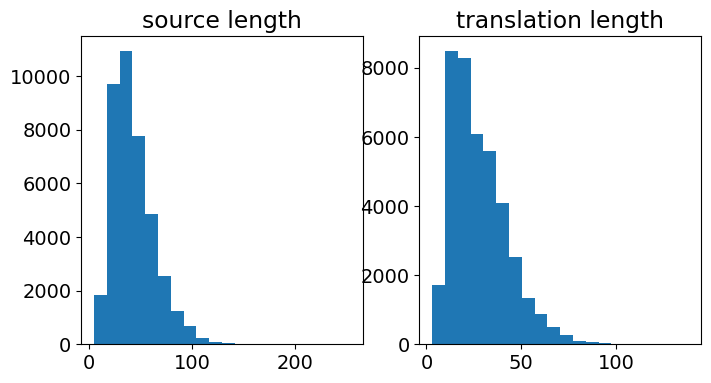

In [33]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["train"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["train"]])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


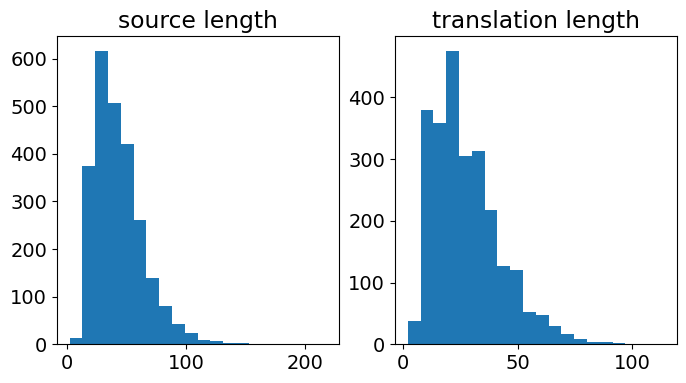

In [69]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["test"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["test"]])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

##### Эксперимент 2: SentencePiece tokenizer

In [99]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input=DATASET_FPATH,
    model_prefix="spm",
    vocab_size=16000,
    model_type="bpe",
    
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,

    pad_piece="<pad>",
    bos_piece="<s>",
    eos_piece="</s>",
    unk_piece="<unk>"
)
tokenizer = spm.SentencePieceProcessor()
tokenizer.load("spm.model")

True

In [100]:
print(tokenizer)

<sentencepiece.SentencePieceProcessor; proxy of <Swig Object of type 'sentencepiece::SentencePieceProcessor *' at 0x000001BD00D20C60> >


In [101]:
tokenizer.encode(r"Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.", out_type=str)

['▁Отель',
 '▁Cord',
 'elia',
 '▁расположен',
 '▁в',
 '▁Тбилиси',
 ',',
 '▁в',
 '▁3',
 '▁минутах',
 '▁ходьбы',
 '▁от',
 '▁Свя',
 'то',
 '-',
 'Т',
 'ро',
 'иц',
 'кого',
 '▁собора',
 '.']

In [113]:
PAD_IDX = tokenizer.pad_id()
PAD_IDX

0

In [103]:
def preprocess_function(examples, max_length=128, source_lang="ru", target_lang="en"):
    inputs = [f[source_lang] for f in examples["translation"]]
    targets = [f[target_lang] for f in examples["translation"]]

    model_inputs = {"input_ids": [tokenizer.encode_as_ids(text) for text in inputs]}
    labels = {"input_ids": [tokenizer.encode_as_ids(text) for text in targets]}

    padded_input_ids = []
    for ids in model_inputs["input_ids"]:
        if len(ids) > max_length:
            padded_input_ids.append(ids[:max_length])
        else:
            # padded_input_ids.append(ids + [tokenizer.pad_id()] * (max_length - len(ids)))
            padded_input_ids.append(ids + [PAD_IDX] * (max_length - len(ids)))
    model_inputs["input_ids"] = padded_input_ids
    model_inputs["attention_mask"] = [[1 if token_id != tokenizer.pad_id() else 0 for token_id in ids] for ids in padded_input_ids]

    padded_labels = []
    for ids in labels["input_ids"]:
        if len(ids) > max_length:
            padded_labels.append(ids[:max_length])
        else:
            # padded_labels.append(ids + [tokenizer.pad_id()] * (max_length - len(ids)))
            padded_labels.append(ids + [PAD_IDX] * (max_length - len(ids)))
    labels["input_ids"] = padded_labels

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [104]:
tokenized_dataset = my_dataset.map(preprocess_function, batched=True, remove_columns=my_dataset["train"].column_names)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7499 [00:00<?, ? examples/s]

Map:   0%|          | 0/2501 [00:00<?, ? examples/s]

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__



---



#### Base version

Базовые версии из файла my_network.py

In [24]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
#         self.dropout = dropout

        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=emb_dim
        )
            # <YOUR CODE HERE>

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )
            # <YOUR CODE HERE>

        self.dropout = nn.Dropout(p=dropout)# <YOUR CODE HERE>

    def forward(self, src):

        #src = [src sent len, batch size]

        # Compute an embedding from the src data and apply dropout to it
        embedded = self.embedding(src)# <YOUR CODE HERE>

        embedded = self.dropout(embedded)

        output, (hidden, cell) = self.rnn(embedded)
        #embedded = [src sent len, batch size, emb dim]

        # Compute the RNN output values of the encoder RNN.
        # outputs, hidden and cell should be initialized here. Refer to nn.LSTM docs ;)

        # <YOUR CODE HERE>

        #outputs = [src sent len, batch size, hid dim * n directions]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #outputs are always from the top hidden layer

        return hidden, cell

In [25]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.output_dim = output_dim
        self.n_layers = n_layers
        self.dropout = dropout

        self.embedding = nn.Embedding(
            num_embeddings=output_dim,
            embedding_dim=emb_dim
        )
            # <YOUR CODE HERE>

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )
            # <YOUR CODE HERE>

        self.out = nn.Linear(
            in_features=hid_dim,
            out_features=output_dim
        )
            # <YOUR CODE HERE>

        self.dropout = nn.Dropout(p=dropout)# <YOUR CODE HERE>

    def forward(self, input, hidden, cell):

        #input = [batch size]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #n directions in the decoder will both always be 1, therefore:
        #hidden = [n layers, batch size, hid dim]
        #context = [n layers, batch size, hid dim]

        input = input.unsqueeze(0)

        #input = [1, batch size]

        # Compute an embedding from the input data and apply dropout to it
        embedded = self.dropout(self.embedding(input))# <YOUR CODE HERE>

        #embedded = [1, batch size, emb dim]

        # Compute the RNN output values of the encoder RNN.
        # outputs, hidden and cell should be initialized here. Refer to nn.LSTM docs ;)
        # <YOUR CODE HERE>


        #output = [sent len, batch size, hid dim * n directions]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #sent len and n directions will always be 1 in the decoder, therefore:
        #output = [1, batch size, hid dim]
        #hidden = [n layers, batch size, hid dim]
        #cell = [n layers, batch size, hid dim]


        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.out(output.squeeze(0))

        #prediction = [batch size, output dim]

        return prediction, hidden, cell

In [26]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"


    def forward(self, src, trg, teacher_forcing_ratio = 0.5):

        #src = [src sent len, batch size]
        #trg = [trg sent len, batch size]
        #teacher_forcing_ratio is probability to use teacher forcing
        #e.g. if teacher_forcing_ratio is 0.75 we use ground-truth inputs 75% of the time

        # Again, now batch is the first dimention instead of zero
        batch_size = trg.shape[1]
        max_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        #tensor to store decoder outputs
        outputs = torch.zeros(max_len, batch_size, trg_vocab_size).to(self.device)

        #last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)

        #first input to the decoder is the <sos> tokens
        input = trg[0,:]

        for t in range(1, max_len):

            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.max(1)[1]
            input = (trg[t] if teacher_force else top1)

        return outputs




---



#### Train functions

In [19]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):

        src = batch['input_ids'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]
        trg = batch['labels'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]

        optimizer.zero_grad()

        output = model(src, trg)

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        # output = output[1:].view(-1, output.shape[-1])
        # trg = trg[1:].view(-1)
        output = output[1:].reshape(-1, output.shape[-1])
        trg = trg[1:].reshape(-1)

        #trg = [(trg sent len - 1) * batch size]
        #output = [(trg sent len - 1) * batch size, output dim]

        loss = criterion(output, trg)

        loss.backward()

        # Let's clip the gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        history.append(loss.cpu().data.numpy())
        if (i+1)%10==0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

            clear_output(True)
            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title('Train loss')
            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')
            plt.legend()

            plt.show()


    return epoch_loss / len(iterator)

In [20]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    history = []

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch['input_ids'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]
            trg = batch['labels'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg sent len, batch size]
            #output = [trg sent len, batch size, output dim]

            output = output[1:].reshape(-1, output.shape[-1])
            trg = trg[1:].reshape(-1)

            #trg = [(trg sent len - 1) * batch size]
            #output = [(trg sent len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [21]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

#### Model

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [23]:
clean_memory()

In [24]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

#### Experiment 1

In [239]:
# def _len_sort_key(x):
#     return len(x.src)

# BATCH_SIZE = 128

# train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
#     (train_data, valid_data, test_data),
#     batch_size = BATCH_SIZE,
#     device = device,
#     sort_key=_len_sort_key
# )

In [240]:
# for x in train_iterator:
#     break
# print(x)
# print(x.src.shape, x.trg.shape)

In [66]:
# INPUT_DIM = len(SRC.vocab)
# OUTPUT_DIM = len(TRG.vocab)
INPUT_DIM = tokenizer.vocab_size
OUTPUT_DIM = tokenizer.vocab_size
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [67]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(62518, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(62518, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (out): Linear(in_features=512, out_features=62518, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [68]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 71,437,366 trainable parameters


In [69]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [71]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

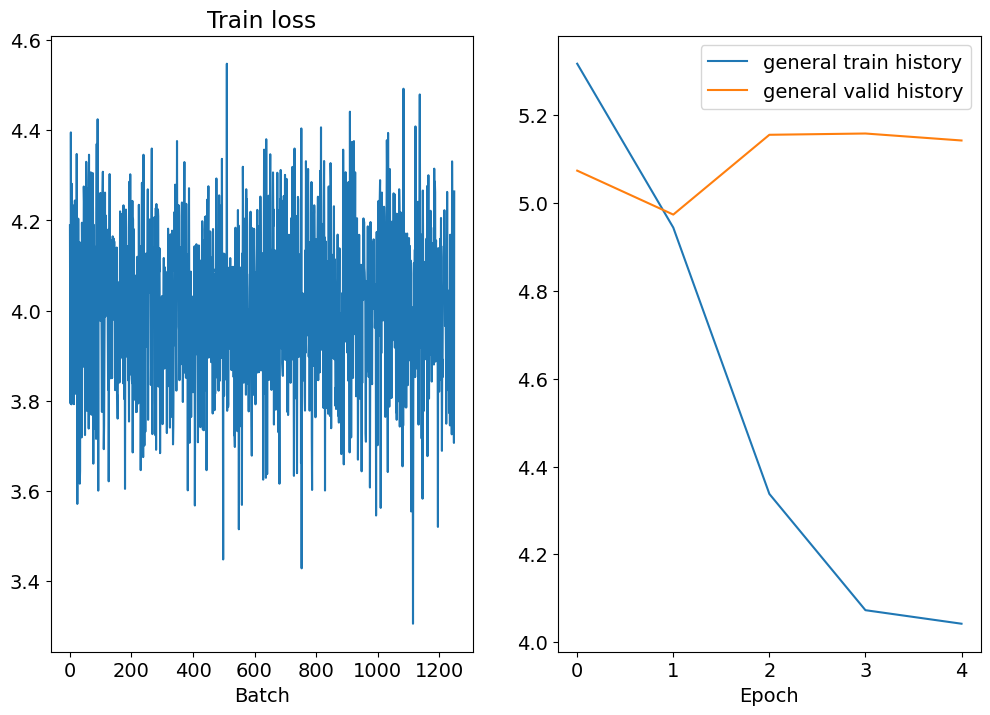

Epoch: 06 | Time: 11m 58s
	Train Loss: 4.005 | Train PPL:  54.857
	 Val. Loss: 5.152 |  Val. PPL: 172.824


KeyboardInterrupt: 

In [72]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()
    
    end_time = time.time()


    
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

#### Experiment 2

In [25]:
from torch.utils.data import DataLoader

In [26]:
def data_collator(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    attention_mask = torch.tensor([item['attention_mask'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

In [27]:
BATCH_SIZE = 32 # 64  # 128

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
valid_dataloader = DataLoader(
    tokenized_dataset["validation"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    tokenized_dataset["test"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)

In [28]:
import my_network
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

In [29]:
tokenizer.vocab_size()

16000

In [30]:
INPUT_DIM = tokenizer.vocab_size()
OUTPUT_DIM = tokenizer.vocab_size()
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [31]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (out): Linear(in_features=512, out_features=16000, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [32]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 23,756,416 trainable parameters


In [33]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [34]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

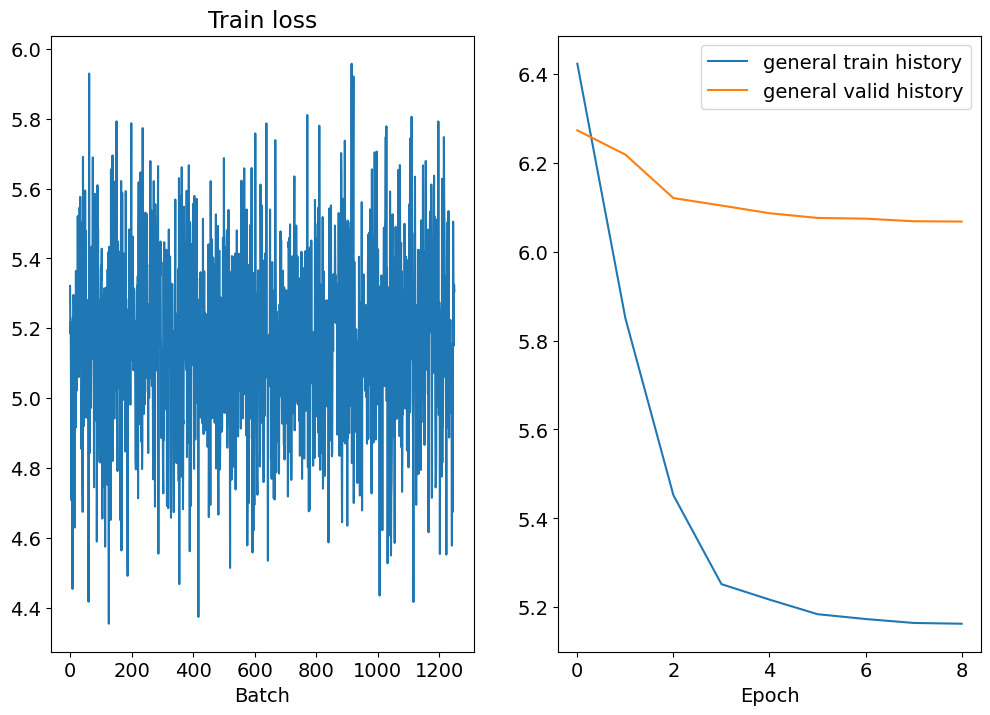

Epoch: 10 | Time: 5m 48s
	Train Loss: 5.161 | Train PPL: 174.289
	 Val. Loss: 6.066 |  Val. PPL: 430.814


In [35]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()
    
    end_time = time.time()
    
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

#### Reference code

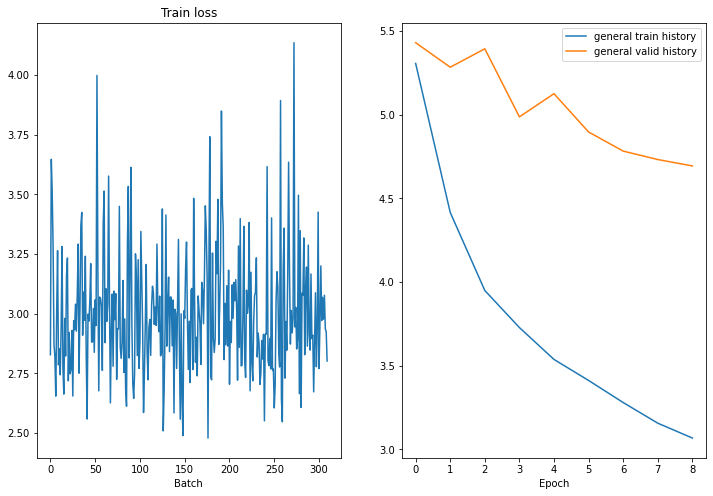

Epoch: 10 | Time: 1m 10s
	Train Loss: 2.998 | Train PPL:  20.040
	 Val. Loss: 4.710 |  Val. PPL: 111.007


In [ ]:
# ===============REFERENCE=================
# for epoch in range(N_EPOCHS):

#     start_time = time.time()

#     train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
#     valid_loss = evaluate(model, valid_iterator, criterion)

#     end_time = time.time()

#     epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#     if valid_loss < best_valid_loss:
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'tut1-model.pt')

#     train_history.append(train_loss)
#     valid_history.append(valid_loss)
#     print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
#     print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
#     print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

#### Quality Eval

__Let's take a look at our network quality__:

In [90]:
try:
    del utils # This line is removed as we redefine functions here.
except:
    pass
# import imp
# imp.reload(utils) # This line is removed as we redefine functions here.
# generate_translation = utils.generate_translation # This line is removed as we redefine functions here.
# remove_tech_tokens = utils.remove_tech_tokens # This line is removed as we redefine functions here.
# get_text = utils.get_text # This line is removed as we redefine functions here.
# flatten = utils.flatten # This line is removed as we redefine functions here.

# Redefine utility functions to use the Hugging Face tokenizer

def remove_tech_tokens(text, tokenizer):
    # Remove special tokens added by the tokenizer
    tokens_to_remove = set(tokenizer.all_special_ids)
    return [token for token in text if tokenizer.convert_tokens_to_ids(token) not in tokens_to_remove]

def decode_without_special_tokens(sp, ids):
    special_ids = {
        sp.pad_id(),
        sp.bos_id(),
        sp.eos_id(),
        sp.unk_id(),
    }
    ids = [i for i in ids if i not in special_ids] # and i != 15884]
    # print(ids)
    
    return sp.decode(ids)    

def get_text(tokens, tokenizer):
    # Decode token IDs back to text
    # Assuming tokens are numpy array of IDs, convert to list for tokenizer
    if isinstance(tokens, torch.Tensor):
        tokens = tokens.tolist()
    elif isinstance(tokens, np.ndarray):
        tokens = tokens.tolist()

    if hasattr(tokenizer, "eos_token_id"):
        EOS_TOKEN_ID = tokenizer.eos_token_id
        PAD_TOKEN_ID = tokenizer.pad_token_id
        BOS_TOKEN_ID = tokenizer.bos_token_id
    else:
        EOS_TOKEN_ID = tokenizer.eos_id()
        PAD_TOKEN_ID = tokenizer.pad_id()
        BOS_TOKEN_ID = tokenizer.bos_id()
    
    # Remove padding and other special tokens for display
    filtered_tokens = []
    for token_id in tokens:
        if token_id == PAD_TOKEN_ID or token_id == EOS_TOKEN_ID or token_id == BOS_TOKEN_ID:
            continue
        filtered_tokens.append(token_id)
    if hasattr(tokenizer, "eos_token_id"):
        return tokenizer.decode(filtered_tokens, skip_special_tokens=True)
    else:
        return decode_without_special_tokens(tokenizer, filtered_tokens)

def generate_translation(src, trg, model, tokenizer, device):
    model.eval()

    # src and trg are expected to be [seq_len, 1] tensors for single example
    # Get source sentence length
    src_len = src.shape[0]

    with torch.no_grad():
        hidden, cell = model.encoder(src.to(device))

    # First input to the decoder is the <sos> token. Using eos_token_id as bos_token_id is None
    # Ensure input is a 1D tensor [token_id] so unsqueeze(0) in decoder makes it [1, 1]
    if hasattr(tokenizer, "eos_token_id"):
        EOS_TOKEN_ID = tokenizer.eos_token_id
    else:
        EOS_TOKEN_ID = tokenizer.eos_id()
        
    input = torch.tensor([EOS_TOKEN_ID], device=device)

    output_tokens = []

    for _ in range(src_len * 2): # Generate up to twice the source length as a heuristic
        with torch.no_grad():
            output, hidden, cell = model.decoder(input, hidden, cell)

        # Get the predicted next token
        pred_token_id = output.argmax(1).item()
        output_tokens.append(pred_token_id)

    
        
        # If we predict the <eos> token, stop
        # if pred_token_id == tokenizer.eos_token_id:
        if pred_token_id == EOS_TOKEN_ID:
            break

        # Next input to the decoder is the predicted token
        input = torch.tensor([pred_token_id], device=device)

    original_text_tokens = src.squeeze(1).tolist()
    target_text_tokens = trg.squeeze(1).tolist()

    print(f"Original: {get_text(original_text_tokens, tokenizer)}")
    print(f"Target: {get_text(target_text_tokens, tokenizer)}")
    print(f"Generated: {get_text(output_tokens, tokenizer)}")

In [97]:
import numpy as np

# The test_dataloader now yields batches as dictionaries
batch = next(iter(test_dataloader))

In [98]:
for idx in [0,1]: # Iterate over a few examples in the batch
    # Extract a single example from the batch
    src_example = batch['input_ids'][idx].unsqueeze(1) # [seq_len, 1]
    trg_example = batch['labels'][idx].unsqueeze(1) # [seq_len, 1]
    generate_translation(src_example, trg_example, model, tokenizer, device)

Original: Предоставляется постельное белье
Target: Extras include bed linen and towels
Generated: the breakfast and be available the
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine
Generated: the, and a can be enjoyed in the


In [93]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [94]:
import tqdm

original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_dataloader)):

        src = batch['input_ids'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]
        trg = batch['labels'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        # Decoding all sequences in the batch
        original_decoded = [get_text(x, tokenizer) for x in trg.cpu().numpy().T]
        generated_decoded = [get_text(x, tokenizer) for x in output[1:].detach().cpu().numpy().T]

        original_text.extend(original_decoded)
        generated_text.extend(generated_decoded)


79it [00:07, 10.11it/s]


In [95]:
# # EXPERIMENT 2
# corpus_bleu([[text] for text in original_text], generated_text) * 100

15.773006910191897

In [78]:
# EXPERIMENT 1
# corpus_bleu([[text] for text in original_text], generated_text) * 100

19.246037756364576

In [75]:
# for idx in [0,1]: # Iterate over a few examples in the batch
#     # Extract a single example from the batch
#     src_example = batch['input_ids'][idx].unsqueeze(1) # [seq_len, 1]
#     trg_example = batch['labels'][idx].unsqueeze(1) # [seq_len, 1]
#     generate_translation(src_example, trg_example, model, tokenizer, device)

Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: re  parking is available on site.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: re                                            .


In [ ]:
# REFERENCE
# corpus_bleu([[text] for text in original_text], generated_text) * 100

14.139920232081806

### Improvements

In [107]:
clean_memory()

In [108]:
import my_network
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

Добавляем Attention (референсная реализация https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html)

In [109]:
INPUT_DIM = tokenizer.vocab_size()
OUTPUT_DIM = tokenizer.vocab_size()
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

import my_network2
Encoder = my_network2.Encoder
Decoder = my_network2.Decoder
Seq2Seq = my_network2.Seq2Seq

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [110]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 256)
    (rnn): LSTM(768, 512, num_layers=2, dropout=0.5)
    (out): Linear(in_features=512, out_features=16000, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (attention): BahdanauAttention(
      (Wa): Linear(in_features=512, out_features=512, bias=True)
      (Ua): Linear(in_features=512, out_features=512, bias=True)
      (Va): Linear(in_features=512, out_features=1, bias=True)
    )
  )
)

In [111]:
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 25,330,817 trainable parameters


In [114]:
import torch.optim.lr_scheduler

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [115]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

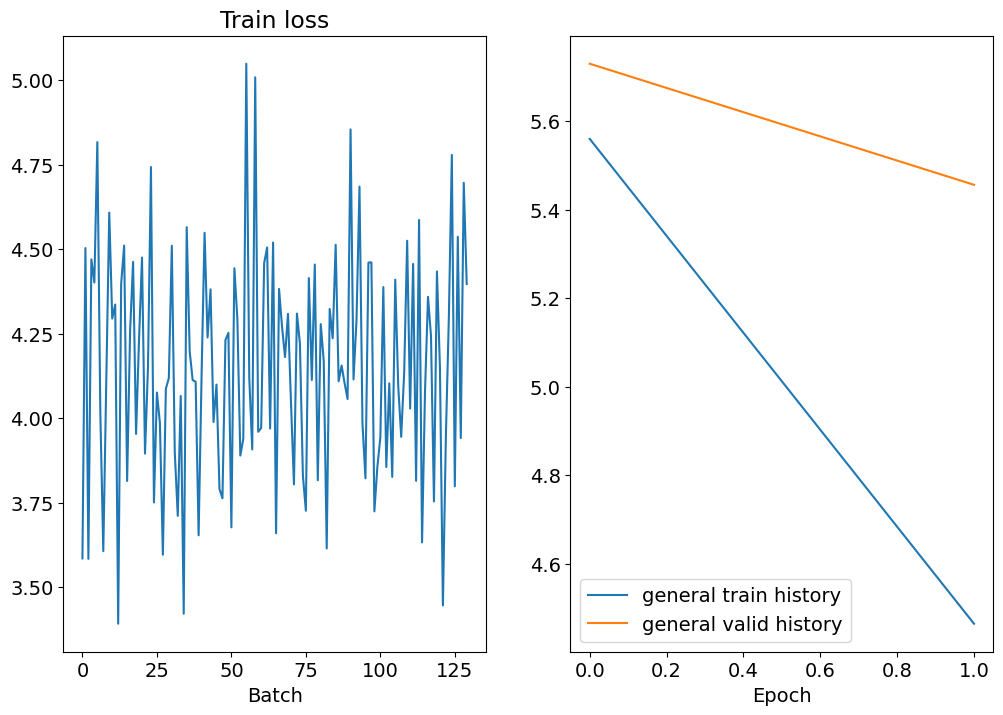

In [ ]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut2-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

### Заключение
0) Во всех экспериментах использовался lr scheduler.
1) Эксперимент 1 с предобученным токенизатором (трансформерная модель Helsinki-NLP/opus-mt-ru-en) получился слишком большой словарь (input_dim=62518), модель обучалась очень долго. Остановлен после 5 эпох. Начальный lr=1e-4, StepLR_scheduler(step_size=3, gamma=0.1). Метрика BLEU~19
2) Эксперимент 2 с SentencePiece токенизатором с ограниченным словарем (input_dim=16000). Начальный lr=1e-3, StepLR_scheduler(step_size=3, gamma=0.1). Метрика BLEU~16
3) Эксперимент 3 с SentencePiece токенизатором с ограниченным словарем (input_dim=16000). В декодер добавлен Attention. Начальный lr=1e-4, StepLR_scheduler(step_size=3, gamma=0.1). Метрика BLEU~